In [124]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [126]:
pd.set_option('display.max_columns', None)

In [128]:
df = pd.read_csv('gurgaon_properties_missing_value_imputation.csv')

In [130]:
df.shape

(3555, 18)

In [132]:
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,house,bptp astaire gardens,sector 70a,6.50,27873.0,4.0,4.0,3+,2.0,New Property,2332.0,1.0,1.0,0.0,1.0,0.0,1.0,160.0
1,house,central park flower valley cerise floors,sector 33,1.35,11157.0,2.0,2.0,2,4.0,New Property,1210.0,1.0,0.0,0.0,0.0,0.0,2.0,107.0
2,flat,emaar gurgaon greens,sector 102,1.45,8788.0,3.0,3.0,3,8.0,Relatively New,1300.0,0.0,1.0,0.0,0.0,0.0,0.0,49.0
3,flat,ss the leaf,sector 85,2.00,8306.0,3.0,4.0,3,8.0,Relatively New,2179.0,0.0,1.0,0.0,0.0,0.0,0.0,21.0
4,flat,orchid petals,sector 49,1.95,9974.0,3.0,3.0,3,2.0,Old Property,1633.0,0.0,0.0,0.0,0.0,0.0,1.0,90.0


In [134]:
train_df = df.drop(columns=['society','price_per_sqft']) # We donot want to take input these column from user 

In [136]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,house,sector 70a,6.50,4.0,4.0,3+,2.0,New Property,2332.0,1.0,1.0,0.0,1.0,0.0,1.0,160.0
1,house,sector 33,1.35,2.0,2.0,2,4.0,New Property,1210.0,1.0,0.0,0.0,0.0,0.0,2.0,107.0
2,flat,sector 102,1.45,3.0,3.0,3,8.0,Relatively New,1300.0,0.0,1.0,0.0,0.0,0.0,0.0,49.0
3,flat,sector 85,2.00,3.0,4.0,3,8.0,Relatively New,2179.0,0.0,1.0,0.0,0.0,0.0,0.0,21.0
4,flat,sector 49,1.95,3.0,3.0,3,2.0,Old Property,1633.0,0.0,0.0,0.0,0.0,0.0,1.0,90.0


### luxury score

In [139]:
# Converting luxury_score column into categorical column

<Axes: ylabel='luxury_score'>

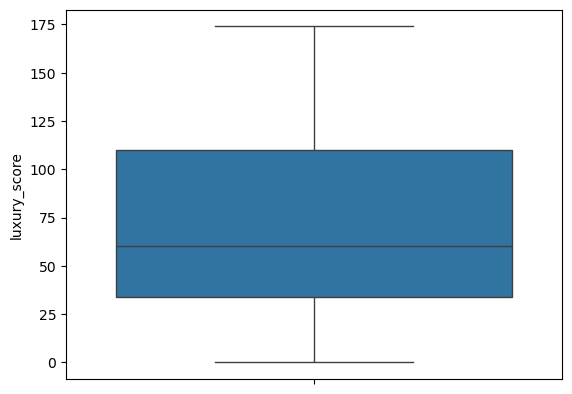

In [141]:
sns.boxplot(df['luxury_score'])

In [143]:
def categorize_luxury(score):
    if 0 <= score < 50:
        return "Low"
    elif 50 <= score < 150:
        return "Medium"
    elif 150 <= score <= 175:
        return "High"
    else:
        return None  # or "Undefined" or any other label for scores outside the defined bins

In [145]:
train_df['luxury_category'] = train_df['luxury_score'].apply(categorize_luxury)

In [147]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,luxury_category
0,house,sector 70a,6.50,4.0,4.0,3+,2.0,New Property,2332.0,1.0,1.0,0.0,1.0,0.0,1.0,160.0,High
1,house,sector 33,1.35,2.0,2.0,2,4.0,New Property,1210.0,1.0,0.0,0.0,0.0,0.0,2.0,107.0,Medium
2,flat,sector 102,1.45,3.0,3.0,3,8.0,Relatively New,1300.0,0.0,1.0,0.0,0.0,0.0,0.0,49.0,Low
3,flat,sector 85,2.00,3.0,4.0,3,8.0,Relatively New,2179.0,0.0,1.0,0.0,0.0,0.0,0.0,21.0,Low
4,flat,sector 49,1.95,3.0,3.0,3,2.0,Old Property,1633.0,0.0,0.0,0.0,0.0,0.0,1.0,90.0,Medium


### floorNum

In [150]:
# Converting it into categorical column

<Axes: ylabel='floorNum'>

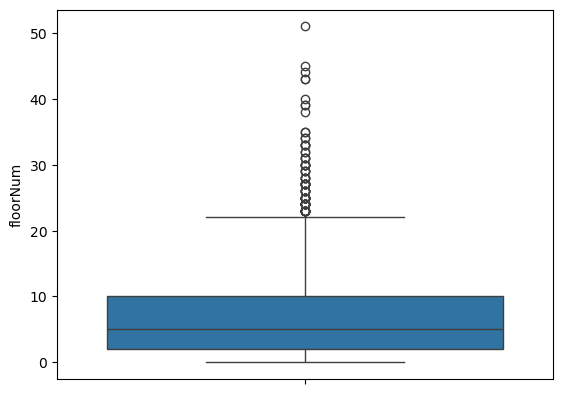

In [152]:
sns.boxplot(df['floorNum'])

In [154]:
def categorize_floor(floor):
    if 0 <= floor <= 2:
        return "Low Floor"
    elif 3 <= floor <= 10:
        return "Mid Floor"
    elif 11 <= floor <= 51:
        return "High Floor"
    else:
        return None  # or "Undefined" or any other label for floors outside the defined bins

In [156]:
train_df['floor_category'] = train_df['floorNum'].apply(categorize_floor)

In [158]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,luxury_category,floor_category
0,house,sector 70a,6.50,4.0,4.0,3+,2.0,New Property,2332.0,1.0,1.0,0.0,1.0,0.0,1.0,160.0,High,Low Floor
1,house,sector 33,1.35,2.0,2.0,2,4.0,New Property,1210.0,1.0,0.0,0.0,0.0,0.0,2.0,107.0,Medium,Mid Floor
2,flat,sector 102,1.45,3.0,3.0,3,8.0,Relatively New,1300.0,0.0,1.0,0.0,0.0,0.0,0.0,49.0,Low,Mid Floor
3,flat,sector 85,2.00,3.0,4.0,3,8.0,Relatively New,2179.0,0.0,1.0,0.0,0.0,0.0,0.0,21.0,Low,Mid Floor
4,flat,sector 49,1.95,3.0,3.0,3,2.0,Old Property,1633.0,0.0,0.0,0.0,0.0,0.0,1.0,90.0,Medium,Low Floor


In [160]:
# As we created 2 new column so we donot need these old column
train_df.drop(columns=['floorNum','luxury_score'],inplace=True)

In [162]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,house,sector 70a,6.50,4.0,4.0,3+,New Property,2332.0,1.0,1.0,0.0,1.0,0.0,1.0,High,Low Floor
1,house,sector 33,1.35,2.0,2.0,2,New Property,1210.0,1.0,0.0,0.0,0.0,0.0,2.0,Medium,Mid Floor
2,flat,sector 102,1.45,3.0,3.0,3,Relatively New,1300.0,0.0,1.0,0.0,0.0,0.0,0.0,Low,Mid Floor
3,flat,sector 85,2.00,3.0,4.0,3,Relatively New,2179.0,0.0,1.0,0.0,0.0,0.0,0.0,Low,Mid Floor
4,flat,sector 49,1.95,3.0,3.0,3,Old Property,1633.0,0.0,0.0,0.0,0.0,0.0,1.0,Medium,Low Floor


In [164]:
# Converting categorical column into numeric

In [166]:
from sklearn.preprocessing import OrdinalEncoder

# Create a copy of the original data for label encoding
data_label_encoded = train_df.copy()

categorical_cols = train_df.select_dtypes(include=['object']).columns

# Apply label encoding to categorical columns
for col in categorical_cols:
    oe = OrdinalEncoder()
    data_label_encoded[col] = oe.fit_transform(data_label_encoded[[col]])
    print(oe.categories_)

[array(['flat', 'house'], dtype=object)]
[array(['dwarka expressway', 'gwal pahari', 'manesar', 'new',
       'new sector 2', 'sector 1', 'sector 102', 'sector 103',
       'sector 104', 'sector 105', 'sector 106', 'sector 107',
       'sector 108', 'sector 109', 'sector 10a', 'sector 11',
       'sector 110', 'sector 111', 'sector 112', 'sector 113',
       'sector 12', 'sector 13', 'sector 14', 'sector 15', 'sector 17',
       'sector 17a', 'sector 17b', 'sector 2', 'sector 21', 'sector 22',
       'sector 23', 'sector 24', 'sector 25', 'sector 26', 'sector 27',
       'sector 28', 'sector 3', 'sector 3 phase 2',
       'sector 3 phase 3 extension', 'sector 30', 'sector 31',
       'sector 33', 'sector 36', 'sector 36a', 'sector 37', 'sector 37c',
       'sector 37d', 'sector 38', 'sector 39', 'sector 4', 'sector 40',
       'sector 41', 'sector 43', 'sector 45', 'sector 46', 'sector 47',
       'sector 48', 'sector 49', 'sector 5', 'sector 50', 'sector 51',
       'sector 52', 'sect

In [168]:
# Splitting the dataset into training and testing sets
X_label = data_label_encoded.drop('price', axis=1)
y_label = data_label_encoded['price']

In [170]:
X_label

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,1.0,83.0,4.0,4.0,4.0,1.0,2332.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0
1,1.0,41.0,2.0,2.0,2.0,1.0,1210.0,1.0,0.0,0.0,0.0,0.0,2.0,2.0,2.0
2,0.0,6.0,3.0,3.0,3.0,3.0,1300.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,2.0
3,0.0,99.0,3.0,4.0,3.0,3.0,2179.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,2.0
4,0.0,57.0,3.0,3.0,3.0,2.0,1633.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3550,0.0,12.0,4.0,5.0,3.0,1.0,2343.0,1.0,1.0,0.0,0.0,0.0,2.0,2.0,0.0
3551,0.0,7.0,4.0,5.0,4.0,1.0,2416.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3552,0.0,96.0,3.0,3.0,4.0,3.0,1668.0,0.0,0.0,0.0,0.0,1.0,2.0,0.0,2.0
3553,0.0,71.0,3.0,4.0,4.0,4.0,1174.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [172]:
y_label

0       6.50
1       1.35
2       1.45
3       2.00
4       1.95
        ... 
3550    4.10
3551    2.00
3552    1.59
3553    3.90
3554    2.90
Name: price, Length: 3555, dtype: float64

### Technique 1 - Correlation Analysis

<Axes: >

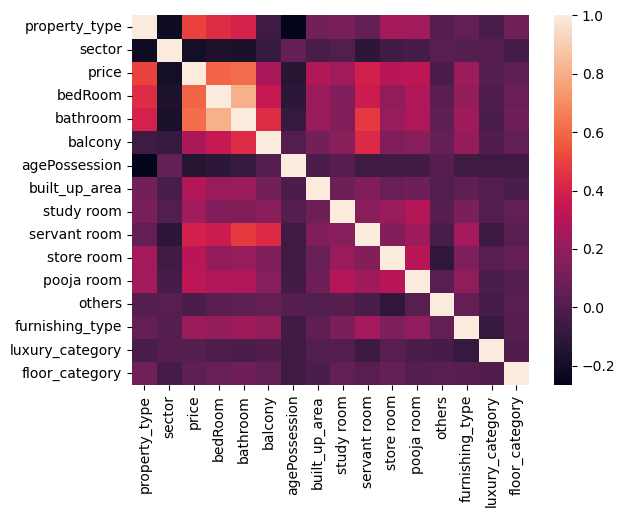

In [174]:
 sns.heatmap(data_label_encoded.corr())

In [176]:
fi_df1 = data_label_encoded.corr()['price'].iloc[1:].to_frame().reset_index().rename(columns={'index':'feature','price':'corr_coeff'})
fi_df1

,feature,corr_coeff
0,sector,-0.200540
1,price,1.000000
2,bedRoom,0.588920
3,bathroom,0.611337
4,balcony,0.271692
5,agePossession,-0.136024
6,built_up_area,0.290228
7,study room,0.240678
8,servant room,0.393022
9,store room,0.310670


### Technique 2 - Random Forest Feature Importance

In [178]:
from sklearn.ensemble import RandomForestRegressor

# Train a Random Forest regressor on label encoded data
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_label, y_label)

# Extract feature importance scores for label encoded data
fi_df2 = pd.DataFrame({
    'feature': X_label.columns,
    'rf_importance': rf_label.feature_importances_
}).sort_values(by='rf_importance', ascending=False)

fi_df2

,feature,rf_importance
6,built_up_area,0.628267
0,property_type,0.114877
1,sector,0.105040
2,bedRoom,0.027605
3,bathroom,0.026983
8,servant room,0.023107
5,agePossession,0.014560
4,balcony,0.012831
12,furnishing_type,0.009935
9,store room,0.007736


### Technique 3 - Gradient Boosting Feature importances

In [180]:
from sklearn.ensemble import GradientBoostingRegressor

# Train a Random Forest regressor on label encoded data
gb_label = GradientBoostingRegressor()
gb_label.fit(X_label, y_label)

# Extract feature importance scores for label encoded data
fi_df3 = pd.DataFrame({
    'feature': X_label.columns,
    'gb_importance': gb_label.feature_importances_
}).sort_values(by='gb_importance', ascending=False)

fi_df3

,feature,gb_importance
6,built_up_area,0.663740
0,property_type,0.102586
1,sector,0.102164
2,bedRoom,0.042487
3,bathroom,0.039201
8,servant room,0.028690
9,store room,0.006808
5,agePossession,0.006029
12,furnishing_type,0.002940
7,study room,0.001644


### Technique 4 - Permutation Importance

In [182]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

X_train_label, X_test_label, y_train_label, y_test_label = train_test_split(X_label, y_label, test_size=0.2, random_state=42)

# Train a Random Forest regressor on label encoded data
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_train_label, y_train_label)

# Calculate Permutation Importance
perm_importance = permutation_importance(rf_label, X_test_label, y_test_label, n_repeats=30, random_state=42)

# Organize results into a DataFrame
fi_df4 = pd.DataFrame({
    'feature': X_label.columns,
    'permutation_importance': perm_importance.importances_mean
}).sort_values(by='permutation_importance', ascending=False)

fi_df4

,feature,permutation_importance
6,built_up_area,0.676299
0,property_type,0.191536
1,sector,0.129383
8,servant room,0.013452
2,bedRoom,0.007000
3,bathroom,0.003454
14,floor_category,0.002584
13,luxury_category,0.001224
10,pooja room,0.000734
5,agePossession,0.000532


### Technique 5 - LASSO

In [186]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_label)

# Train a LASSO regression model
# We'll use a relatively small value for alpha (the regularization strength) for demonstration purposes
lasso = Lasso(alpha=0.01, random_state=42)
lasso.fit(X_scaled, y_label)

# Extract coefficients
fi_df5 = pd.DataFrame({
    'feature': X_label.columns,
    'lasso_coeff': lasso.coef_
}).sort_values(by='lasso_coeff', ascending=False)

fi_df5

,feature,lasso_coeff
0,property_type,0.770730
3,bathroom,0.605328
2,bedRoom,0.404263
6,built_up_area,0.376551
8,servant room,0.374583
9,store room,0.246365
7,study room,0.214252
12,furnishing_type,0.162772
10,pooja room,0.117216
13,luxury_category,0.085691


### Technique 6 - RFE

In [188]:
from sklearn.feature_selection import RFE

# Initialize the base estimator
estimator = RandomForestRegressor()

# Apply RFE on the label-encoded and standardized training data
selector_label = RFE(estimator, n_features_to_select=X_label.shape[1], step=1)
selector_label = selector_label.fit(X_label, y_label)

# Get the selected features based on RFE
selected_features = X_label.columns[selector_label.support_]

# Extract the coefficients for the selected features from the underlying linear regression model
selected_coefficients = selector_label.estimator_.feature_importances_

# Organize the results into a DataFrame
fi_df6 = pd.DataFrame({
    'feature': selected_features,
    'rfe_score': selected_coefficients
}).sort_values(by='rfe_score', ascending=False)

fi_df6


,feature,rfe_score
6,built_up_area,0.625261
0,property_type,0.113001
1,sector,0.109471
2,bedRoom,0.028262
3,bathroom,0.028182
8,servant room,0.023089
5,agePossession,0.013986
4,balcony,0.012651
12,furnishing_type,0.009936
13,luxury_category,0.007289


### Technique 7 - Linear Regression Weights

In [192]:
from sklearn.linear_model import LinearRegression

In [194]:
# Train a linear regression model on the label-encoded and standardized training data
lin_reg = LinearRegression()
lin_reg.fit(X_scaled, y_label)

# Extract coefficients
fi_df7 = pd.DataFrame({
    'feature': X_label.columns,
    'reg_coeffs': lin_reg.coef_
}).sort_values(by='reg_coeffs', ascending=False)

fi_df7


,feature,reg_coeffs
0,property_type,0.776579
3,bathroom,0.602726
2,bedRoom,0.404209
6,built_up_area,0.383668
8,servant room,0.376852
9,store room,0.248946
7,study room,0.220251
12,furnishing_type,0.170382
10,pooja room,0.120225
13,luxury_category,0.095926


### Technique 8 - SHAP

In [196]:
!pip install shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 897.6 kB/s eta 0:00:0031m71.1 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.5/555.5 kB 2.8 MB/s eta 0:00:00 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 3.9 MB/s eta 0:00:00m eta 0:00:010:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 10.0 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
  Attempting uninstall: joblib
    Found existing installation: joblib 1.1.1
    Uninstalling joblib-1.1.1:
      Successfully uninstalled joblib-1.1.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.0.2 which is incompatible.
streamlit 1.32.0 requires numpy<2,>=1.19.3, but y

In [198]:
import shap

# Compute SHAP values using the trained Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_label, y_label)

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_label)

# Summing the absolute SHAP values across all samples to get an overall measure of feature importance
shap_sum = np.abs(shap_values).mean(axis=0)

shap_values


array([[ 1.72141627e+00, -2.03762527e-01,  5.02094077e-02, ...,
         9.52170905e-03,  4.87380571e-02,  3.03519678e-05],
       [ 5.70043831e-01,  2.55627828e-01, -4.61063101e-02, ...,
         1.74274812e-01,  1.84747212e-02,  8.35005667e-03],
       [-2.66854204e-01, -4.94235860e-02, -2.76236908e-02, ...,
        -9.98627079e-03, -2.37894943e-03, -1.72133266e-02],
       ...,
       [-2.04049976e-01, -2.44936957e-01, -7.56134330e-03, ...,
         1.37458202e-01,  1.52560972e-02, -1.37070611e-02],
       [-2.04320374e-01,  8.71787607e-01, -6.26007591e-03, ...,
         8.74939174e-03,  4.90279551e-02,  6.60210865e-02],
       [-3.78944968e-01,  7.48712830e-01, -4.07036761e-02, ...,
        -1.42131065e-02,  7.90011808e-03, -1.78099666e-02]])

In [200]:
fi_df8 = pd.DataFrame({
    'feature': X_label.columns,
    'SHAP_score': np.abs(shap_values).mean(axis=0)
}).sort_values(by='SHAP_score', ascending=False)

fi_df8

,feature,SHAP_score
6,built_up_area,1.238035
0,property_type,0.499263
1,sector,0.391776
3,bathroom,0.120350
8,servant room,0.098907
2,bedRoom,0.063414
4,balcony,0.042884
5,agePossession,0.028284
12,furnishing_type,0.026114
14,floor_category,0.023738


In [202]:
# mergeing all values

In [204]:
final_fi_df = fi_df1.merge(fi_df2,on='feature').merge(fi_df3,on='feature').merge(fi_df4,on='feature').merge(fi_df5,on='feature').merge(fi_df6,on='feature').merge(fi_df7,on='feature').merge(fi_df8,on='feature').set_index('feature')

In [207]:
final_fi_df


,corr_coeff,rf_importance,gb_importance,permutation_importance,lasso_coeff,rfe_score,reg_coeffs,SHAP_score
feature,,,,,,,,
sector,-0.200540,0.105040,0.102164,0.129383,-0.136547,0.109471,-0.144565,0.391776
bedRoom,0.588920,0.027605,0.042487,0.007000,0.404263,0.028262,0.404209,0.063414
bathroom,0.611337,0.026983,0.039201,0.003454,0.605328,0.028182,0.602726,0.120350
balcony,0.271692,0.012831,0.001493,-0.000709,0.053712,0.012651,0.060678,0.042884
agePossession,-0.136024,0.014560,0.006029,0.000532,-0.006643,0.013986,-0.014031,0.028284
built_up_area,0.290228,0.628267,0.663740,0.676299,0.376551,0.625261,0.383668,1.238035
study room,0.240678,0.006747,0.001644,-0.002325,0.214252,0.007249,0.220251,0.017668
servant room,0.393022,0.023107,0.028690,0.013452,0.374583,0.023089,0.376852,0.098907
store room,0.310670,0.007736,0.006808,-0.004761,0.246365,0.006544,0.248946,0.017004


In [209]:
# normalize the score
final_fi_df = final_fi_df.divide(final_fi_df.sum(axis=0), axis=1)

In [211]:
final_fi_df[['rf_importance','gb_importance','permutation_importance','rfe_score','SHAP_score']].mean(axis=1).sort_values(ascending=False)

feature
built_up_area      0.712469
sector             0.139799
bathroom           0.033475
bedRoom            0.029807
servant room       0.029490
agePossession      0.010607
balcony            0.009993
furnishing_type    0.007378
floor_category     0.005810
luxury_category    0.005230
store room         0.005205
study room         0.004643
pooja room         0.003746
others             0.002348
dtype: float64

In [215]:
# to drop pooja room, study room, others 
# As i saw that it is not that much important for price as all model it 
# is in last
X_label

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,1.0,83.0,4.0,4.0,4.0,1.0,2332.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0
1,1.0,41.0,2.0,2.0,2.0,1.0,1210.0,1.0,0.0,0.0,0.0,0.0,2.0,2.0,2.0
2,0.0,6.0,3.0,3.0,3.0,3.0,1300.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,2.0
3,0.0,99.0,3.0,4.0,3.0,3.0,2179.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,2.0
4,0.0,57.0,3.0,3.0,3.0,2.0,1633.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3550,0.0,12.0,4.0,5.0,3.0,1.0,2343.0,1.0,1.0,0.0,0.0,0.0,2.0,2.0,0.0
3551,0.0,7.0,4.0,5.0,4.0,1.0,2416.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3552,0.0,96.0,3.0,3.0,4.0,3.0,1668.0,0.0,0.0,0.0,0.0,1.0,2.0,0.0,2.0
3553,0.0,71.0,3.0,4.0,4.0,4.0,1174.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# r2 score

In [217]:
# with all the cols
from sklearn.model_selection import cross_val_score

rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X_label, y_label, cv=5, scoring='r2')

In [218]:
scores.mean()

0.8102213004534544

In [ ]:
# r2 score without these column

In [221]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X_label.drop(columns=['pooja room', 'study room', 'others']), y_label, cv=5, scoring='r2')

In [222]:
scores.mean()

0.8092050248531544

In [225]:
export_df = X_label.drop(columns=['pooja room', 'study room', 'others'])
export_df['price'] = y_label

In [227]:
export_df.to_csv('gurgaon_properties_post_feature_selection.csv', index=False)

In [229]:
export_df

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,store room,furnishing_type,luxury_category,floor_category,price
0,1.0,83.0,4.0,4.0,4.0,1.0,2332.0,1.0,0.0,1.0,0.0,1.0,6.50
1,1.0,41.0,2.0,2.0,2.0,1.0,1210.0,0.0,0.0,2.0,2.0,2.0,1.35
2,0.0,6.0,3.0,3.0,3.0,3.0,1300.0,1.0,0.0,0.0,1.0,2.0,1.45
3,0.0,99.0,3.0,4.0,3.0,3.0,2179.0,1.0,0.0,0.0,1.0,2.0,2.00
4,0.0,57.0,3.0,3.0,3.0,2.0,1633.0,0.0,0.0,1.0,2.0,1.0,1.95
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3550,0.0,12.0,4.0,5.0,3.0,1.0,2343.0,1.0,0.0,2.0,2.0,0.0,4.10
3551,0.0,7.0,4.0,5.0,4.0,1.0,2416.0,1.0,0.0,0.0,1.0,0.0,2.00
3552,0.0,96.0,3.0,3.0,4.0,3.0,1668.0,0.0,0.0,2.0,0.0,2.0,1.59
3553,0.0,71.0,3.0,4.0,4.0,4.0,1174.0,1.0,0.0,0.0,0.0,0.0,3.90
